# Exploration of datasets

In [1]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization import datasets
from genai_detection.config import CONFIG
from functools import partial
import gc
import datetime
import textwrap
import pyreadstat

In [2]:
def print_min_len_text_sample(df):
    df["text_length"] = df["pair"].apply(
        lambda x: min(len(x[0].split()), len(x[1].split()))
    )
    min_len_texts = df[df["text_length"] == min(df["text_length"])]
    shorter_text = min(min_len_texts["pair"].values[0], key=lambda t: len(t.split()))
    print(
        f"Text with minimal length {len(shorter_text.split())}:\n{textwrap.fill(shorter_text, width=100)}\n"
    )


def print_max_len_text_sample(df):
    df["text_length"] = df["pair"].apply(
        lambda x: min(len(x[0].split()), len(x[1].split()))
    )
    max_len_texts = df[df["text_length"] == max(df["text_length"])]
    longer_text = max(max_len_texts["pair"].values[0], key=lambda t: len(t.split()))
    print(
        f"Text with maximal length {len(longer_text.split())}:\n{textwrap.fill(longer_text, width=100)}"
    )


def _split(text):
    """Split text into sentences."""
    return text.split(" ")

# Student Essay Dataset

In [3]:
path2student_essays = (
    Path(os.getcwd()).resolve().parent / CONFIG.DATA_BASE_PATH / "student_essays/"
)
assert (
    path2student_essays.exists()
), f"Path {path2student_essays} to student essays dataset does not exist."
sav_files = list(path2student_essays.rglob("*.sav"))
assert len(sav_files) > 0, f"No .sav files found in {path2student_essays}."
for file in sav_files:
    assert file.exists(), f"File {file} does not exist."
    # print(f"\n=== {file.name} ===")
    df, meta = pyreadstat.read_sav(file, apply_value_formats=True, metadataonly=False)
    # display(df)   # Uncomment to display the dataframe in Jupyter Notebook, do not commit because sensitive data

In [4]:
import chardet

# build student essays dataset
student_essays_df = pd.DataFrame(
    columns=["author_id", "text", "task", "task_description"]
)
task_description = {
    "Ass1": "Stream of consciousness",
    "Ass2": "Talk about your childhood",
    "Ass3": "Describe your personality",
    "Ass4": "Thematic Apperception Test",
    "Ass5": "Give four examples of four different theories",
}
# iterate over all TXT files in assignment directories and extract the essays
for dir in [f"Ass{i}" for i in range(1, 6)]:
    path2ass_dir = (
        Path(os.getcwd()).resolve().parent
        / CONFIG.DATA_BASE_PATH
        / "student_essays/Intro2006"
        / dir
    )
    assert (
        path2ass_dir.exists()
    ), f'Path {path2ass_dir} to Assignment "{task_description[dir]}" of student essays dataset does not exist.'

    if dir == "Ass5":  # has subtasks (directories)
        text_files = []
        for subtask in path2ass_dir.iterdir():
            text_files.extend(subtask.glob("*.txt"))
    else:
        text_files = path2ass_dir.glob("*.txt")

    for txt_file in text_files:
        with open(txt_file, "rb") as f:
            raw_data = f.read()
            detected = chardet.detect(raw_data)
            encoding = detected["encoding"]

        essay_text = raw_data.decode(encoding)
        student_essays_df = pd.concat(
            [
                student_essays_df,
                pd.DataFrame(
                    [
                        {
                            "author_id": txt_file.stem,
                            "text": essay_text,
                            "task": txt_file.parent.name,
                            "task_description": task_description[dir],
                        }
                    ]
                ),
            ]
        )

display(student_essays_df)

# metadata dataframe
author_metadata_columns = [
    "ID",
    "TEACHER",
    "BIRTHORD",
    "SEX",
    "ETHNIC",
    "POLITOR",
    "YEAR",
]
rename_map = {
    "ID": "author_id",
    "TEACHER": "teacher",
    "BIRTHORD": "birthorder",
    "SEX": "sex",
    "ETHNIC": "ethnicity",
    "POLITOR": "political_orientation",
    "YEAR": "year",
}
raw_metadata, _ = pyreadstat.read_sav(
    Path(os.getcwd()).resolve().parent
    / CONFIG.DATA_BASE_PATH
    / "student_essays/Intro2006/2006Big5xxx.sav",
    apply_value_formats=True,
    metadataonly=False,
)
available_columns = [
    col for col in raw_metadata.columns if col in author_metadata_columns
]
author_metadata = raw_metadata[available_columns].copy()
author_metadata.rename(columns=rename_map, inplace=True)
# keep NaNs, no answer is also an answer group
display(author_metadata)

,author_id,text,task,task_description
0,2006_EFB232,I come from a small town on the coast of Texas...,Ass1,Stream of consciousness
0,2006_VBC75,"Alright, so the first thought in my head is wo...",Ass1,Stream of consciousness
0,2006_SMY244,I don't know why this kind of stuff always hap...,Ass1,Stream of consciousness
0,2006_MM22236,I feel very full at the present time. I had no...,Ass1,Stream of consciousness
0,2006_AUSTINKW,My name is Kyle Austin and my EID is austinkw....,Ass1,Stream of consciousness
...,...,...,...,...
0,JWJ296,My stepmother is extremely prone to committing...,Ass5a,Give four examples of four different theories
0,JDP2276,An example of the fundamental attribution erro...,Ass5a,Give four examples of four different theories
0,CEG588,The only thing I can think of that relates to ...,Ass5a,Give four examples of four different theories
0,KAM2437,Every once in a while I would run into a girl ...,Ass5a,Give four examples of four different theories


,author_id,teacher,sex,ethnicity,birthorder,political_orientation,year
0,144332,Gosling,female,Hispanic,oldest,middle,2.0
1,AA8763,Pennebaker,male,other,oldest,NaN,1.0
2,AAA958,Gosling,female,Hispanic,oldest,middle,1.0
3,AAH683,Pennebaker,male,Asian Amer,second,ext cons,1.0
4,AAH699,Pennebaker,female,Asian Amer,oldest,middle,1.0
...,...,...,...,...,...,...,...
1042,ZH523,Pennebaker,male,Asian Amer,oldest,som lib,3.0
1043,ZL374,Gosling,female,Hispanic,oldest,som lib,2.0
1044,ZLL62,Pennebaker,male,Asian Amer,oldest,ext lib,1.0
1045,ZRP68,Gosling,male,White,oldest,som cons,1.0


In [5]:
# display(student_essays_df[student_essays_df.task=="Ass5a"] )
# display(student_essays_df[student_essays_df.task=="Ass5b"] )
# display(student_essays_df[student_essays_df.task=="Ass5c"] )
# display(student_essays_df[student_essays_df.task=="Ass5d"] )

In [6]:
student_essays = datasets.StudentEssaysVisualization()
ds_student_essays = student_essays.load_dataset()
labels_student_essays = ds_student_essays["same"]
display(ds_student_essays.head())

,pair,authors,same
0,[A big factor that has influnced me and my up ...,"[AAA958, AAA958]",True
1,[I am lauren elise pittman. I come from 2 good...,"[LP962, LP962]",True
2,[Early life for me was rather strange in compa...,"[MJK677, MJK677]",True
3,[The first thing that comes into my mind is at...,"[DDC389, DDC389]",True
4,"[To search for trends, I will start by analyzi...","[WB838, WB838]",True


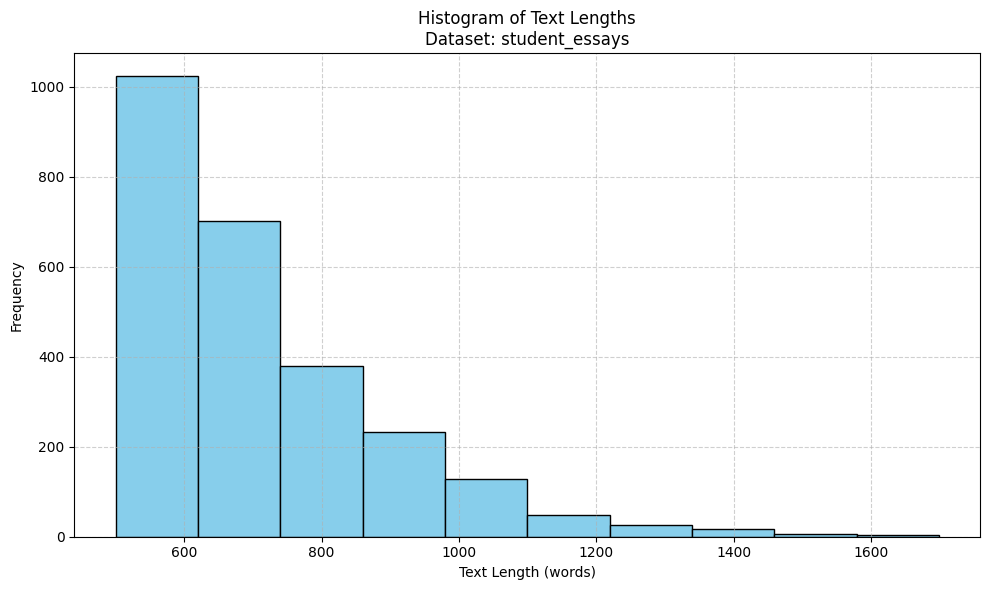

Average length (characters) per text: 708.64


In [7]:
student_essays.plot_text_length_histogram(
    dataset=ds_student_essays, preprocess_fn=_split, unit="words"
)

In [8]:
student_essays_stats = student_essays.dataset_stats()

Display texts of minimal and maximal length from the student essay dataset.

The shortest Student Essay text (500 words) is a (fictional) story about theft of experiment results with a happy ending.

In [9]:
print_min_len_text_sample(ds_student_essays)

Text with minimal length 500:
Who am I? This is an interesting question, do I define myself as others see me or as I see myself?
Truthfully I define myself by how others see me when I am around them, and then I define myself by
how I see me when I'm alone. Others see me as an outgoing person who is fun to hang around with and
enjoys sports, partying and other recreatonal activities. I see myself as a Christian who does enjoy
partying and fitting in, but who can also enjoy being alone and sitting at home watching tv or
playing video games while my friends go out and party. I am who I want to be. I want to be yes more
active and less anti-social at times. I always enjoy being around other people, but I sometimes find
it hard to go up to new people who I don't know and go up to them and just start a conversation with
them. I usually have to be around people I have know for a while and whom I know I can trust or at
least have a good time with. During my childhood I had many friends, both m

The longest Student Essay text (1136 words) is a text about the inner thoughts of a person who seems to think he is manipulative and hurts women without them knowing it after a breakup.

In [10]:
print_max_len_text_sample(ds_student_essays)

Text with maximal length 1410:
Anyway, I'm very disgruntled. I feel this way because I feel that I'm not doing what I was meant to
do. I was meant to become an activist for the Asian-American community. But instead, I am being
forced to study electrical engineering by my parents and by the f it has a lot of job opportunities.
But that is not me at all. I believe in breaking Asian stereotypes and studying electrical
engineering will be anything but breaking stereotypes. In fact, it would be enforcing them and one
of my goals is to show the world that us Asians can do things other than engineering. This isn't
just me and my childhood fantasies. No, this is real. I feel I was meant to be an activist. When I
joined the Asian Culture Committee, I was really involved in it. I'm usually a quiet person but
damn, I was inputting lots of ideas for the group. Why? Because my desire to be an Asian activist is
so immense that it destroyed my shyness. This is my destiny and I cannot let it be interr

In [11]:
# ds_student_essays["text_length"] = ds_student_essays["pair"].apply(lambda x: min(len(x[0].split()), len(x[1].split())))
# min_len_texts = ds_student_essays[ds_student_essays["text_length"] == min(ds_student_essays["text_length"])]
# shorter_text = min(min_len_texts['pair'].values[0], key=lambda t: len(t.split()))
# # print(f"Text with minimal length {len(shorter_text.split())}:\n{textwrap.fill(shorter_text, width=100)}\n")

# max_len_texts = ds_student_essays[ds_student_essays["text_length"] == max(ds_student_essays["text_length"])]
# longer_text = max(max_len_texts['pair'].values[0], key=lambda t: len(t.split()))
# print(f"Text with maximal length {len(longer_text.split())}:\n{textwrap.fill(longer_text, width=100)}")

In [12]:
del student_essays
del ds_student_essays
gc.collect()

3571

## PAN 2023

In [13]:
# pan23 = datasets.Pan23Visualization()
# ds_pan = pan23.load_dataset()
# labels = ds_pan['same']
# display(ds_pan.head())

In [14]:
# labels.value_counts()

In [15]:
# pan23_stats = pan23.dataset_stats()

In [16]:
# pan23.plot_avg_text_length_per_author()
# pan23.plot_text_length_histogram(bins=50)
# pan23.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del pan23
# gc.collect()

## PAN 20

In [17]:
pan20 = datasets.Pan20Visualization()
ds_pan20 = pan20.load_dataset()
labels_pan20 = ds_pan20["same"]
display(ds_pan20.head())

,id,fandoms,pair,same,authors
0,6cced668-6e51-5212-873c-717f2bc91ce6,"[Guardians of Ga'Hoole, Hetalia - Axis Powers]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
1,3c6c188a-db28-59aa-8c09-3d0f799ff579,"[Guardians of Ga'Hoole, Warriors]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
2,b0cfa94f-c9ec-5aa5-8331-a5a249b664cf,"[Guardians of Ga'Hoole, Xiaolin Showdown]",[A single tear escaped me as I left. I did hav...,True,"[1446633, 1446633]"
3,e6e86e73-9a7b-58f2-a652-a17b4a1bcabf,"[Hetalia - Axis Powers, Warriors]","[""Ja."" Ludwig kept his gaze upon her, solidly....",True,"[1446633, 1446633]"
4,4fe541af-912e-5a86-81a5-94c6d3891509,"[Hetalia - Axis Powers, Xiaolin Showdown]","[And he did. Slowly, hesitantly...but coming f...",True,"[1446633, 1446633]"


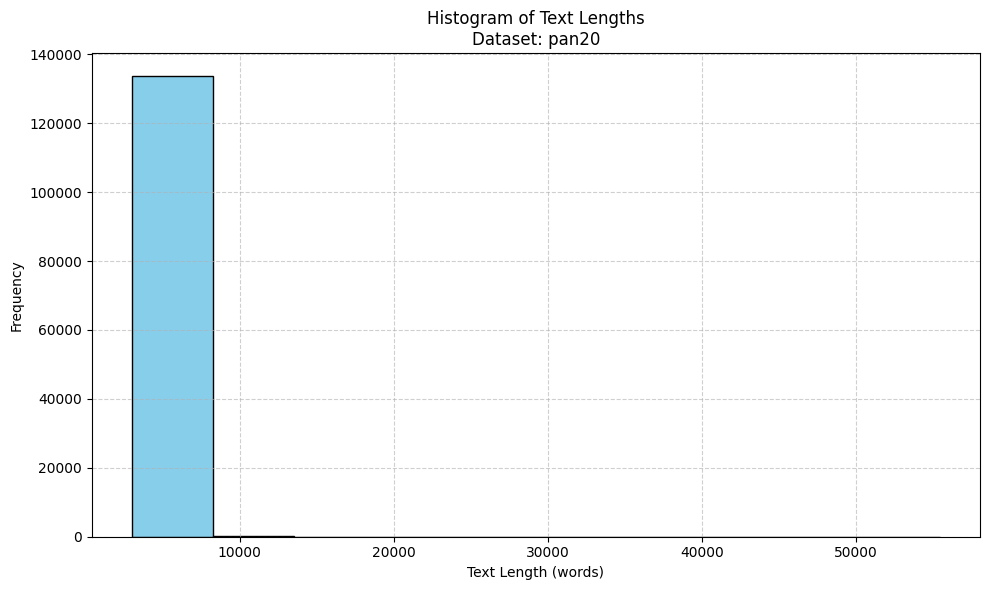

Average length (characters) per text: 3915.17


In [18]:
pan20.plot_text_length_histogram(dataset=ds_pan20, preprocess_fn=_split, unit="words")

The shortest PAN20 text (505 words) does not really make sense.

In [19]:
print_min_len_text_sample(ds_pan20)

Text with minimal length 3044:
Meis: ...............Kyleen! How did you get here so fast?! Were you lurking around in the bushes?!
Oran and Achika: OO? CPsCartoons: Kyleen: "What are ya, blind? Everyone just pops up around here!"
^^ Mocchi: *pops up* OO? hollychan5: Meis: I know that, but knowing you, you would more likely be
lurking around, trying to steal money or something. CPsCartoons: Kyleen: "Um...no..." *Runs away*
Sodina: "...My wallet...! KYLEEN!!!" *Runs after her with her knife* hollychan5: (The Slayers Try
Korean opening is cool. ^^..........I should get KC to translate it one day... :\) Koti:
.......Daddy.....? ;;'' Meis: Don"t ask. Just don"t ask......hey.....where"s my money pouch?! Hare:
*Sneaks off w/ a money pouch* Heheheh....gold.....gold....... CPsCartoons: (Ohkay... ^^; ) Holly
*appears out of the shadows*: ==+ Hare: O.O *Drops puch and runs like hell* hollychan5: (....What?)
Meis: *As Hare runs by* .............um........ Koti: *Walks over to bushes, then comes ba

The longest PAN20 text (55,406 words) seems to be a book with multiple chapters.

In [20]:
print_max_len_text_sample(ds_pan20)

Text with maximal length 55406:
Chapter 1 The sun had risen on their last day in the port of Sinjai, the final destination before
returning to Basra with the sultan Omar"s supplies. There would be a late tide so Sinbad gave shore
leave to all but himself and 3 members of the crew with orders to have fun but return in shape to
weigh anchor at the evening"s high tide. Firouz decided to remain on board as well. He had been
working on some experiments that needed his undivided attention. Garret was in charge of the cargo.
He had to itemize the sultan"s wares. The other two crewmen were young and wet behind the ears. They
had come aboard in Basra and were too excited to be a part of Sinbad"s crew to care about shore
leave. They had offered to help Garret in exchange for some sparring against the captain"s sword.
Sinbad had learned to fight in a similar manner and in fact, was honored that they felt his skills
where worth losing a day of shore leave. Unlike Sinbad however, who was new at the

In [21]:
# labels_pan20.value_counts()

In [22]:
pan20_stats = pan20.dataset_stats()

In [23]:
# pan20.plot_text_length_histogram(bins=50)

In [24]:
# def normalize_text(text):
#     stemmer = SnowballStemmer('english')
#     return ' '.join(stemmer.stem(w) for w in text.lower().split())

In [25]:
# FIXME: kernel fails

# impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True)

# preproc_fn = partial(impostor_det.tokenize_char_ngrams, n=4, normalize_ws=True, space_free=True)
# pan20.plot_text_length_histogram(bins=50, preprocess_fn=preproc_fn)

In [26]:
# pan20.plot_avg_text_length_per_author()

In [27]:
# pan20.plot_avg_text_length_per_author(unit='ngrams')

In [28]:
# pan20.boxplots_text_len_ngrams()

In [29]:
# Python garbage collector to release memory
del pan20
gc.collect()

3656

## Blog Corpus

In [30]:
blog = datasets.BlogVisualization()

In [31]:
ds_blog = blog.load_dataset()

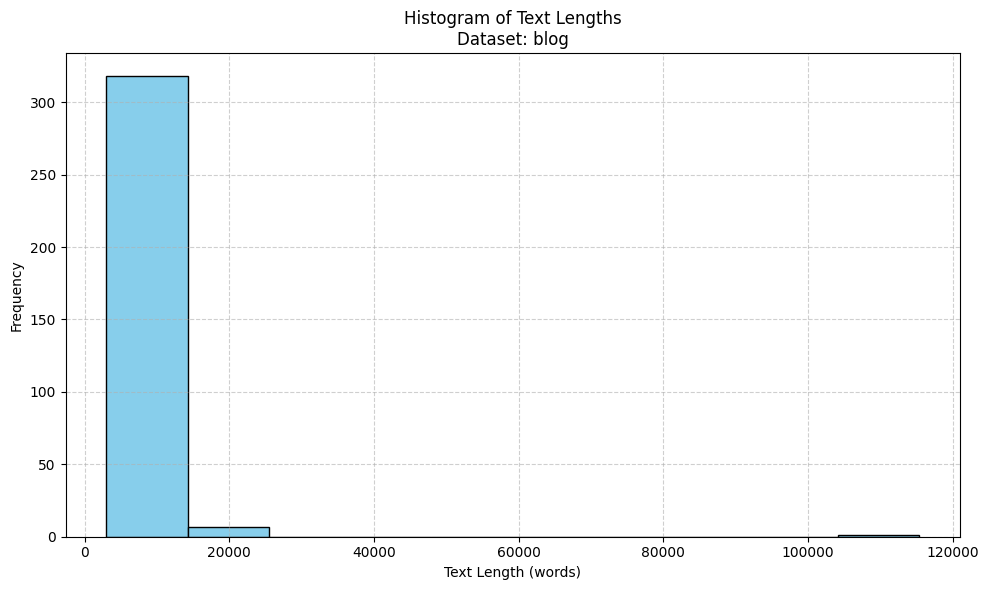

Average length (characters) per text: 5386.24


In [32]:
blog.plot_text_length_histogram(dataset=ds_blog, preprocess_fn=_split, unit="words")

The shortest blog text (500 words) is an experience report from a McLachlan concert.

In [33]:
print_min_len_text_sample(ds_blog)

Text with minimal length 3009:
BitterSid: hi SmarterChild: Hi BitterSid, I'm SmarterChild! I'm your new robot friend. I bring you
the info you want faster and easier than ever! Click here to see my privacy policy. Your 30-day free
trial starts now. I can't wait to show you what I can do, but first I'd like get to know you a
little. May I ask you a few general questions? (To do this later, type 'skip.' You can also skip any
question.) BitterSid: sure SmarterChild: Cool! OK, let's get started. To skip any question, type
'skip.' To exit the interview, type 'exit.' What's your first name? (If you want me to call you
BitterSid, type 'none.') BitterSid: josh SmarterChild: Cool, I'll call you Josh now. Do you go to
school? BitterSid: yep SmarterChild: Are you in high school? BitterSid: sure am SmarterChild: Cool!
What's your favorite class? BitterSid: umm...english i guess SmarterChild: Sorry, I don't recognize
that as the name of a class. Please try again or type 'skip' or 'exit.' BitterSid:

The longest Blog entry (8663 words) seems to be a fictional book/ story.

In [34]:
print_max_len_text_sample(ds_blog)

Text with maximal length 13286:
BOOM! watch your head. what? BOOM! watch your head. -The Ying Yang Twins, 'What's Happenin'?' ONLY
TWO WEEKS LEFT OF SCHOOL! so stoked. i woke up pumped on tuesday. it was a pretty normal day.. in
math we reviewed for the test and crystal and i hung out in the back and talked and stuff. it was
totally funny haha. we made fun of that fat kid in our class. in piano, i hung out with delia and we
talked about EVERYTHING from the sexy and scandalous life of sabrina bedell to the weirdness of
anita lively's brother who is in a mental institution. haha. it was a lotta fun. after that we
talked to joe and YEAH YEAH YEAH! in english we watched the rst of the TKAM video. it was so weird.
that one boo guy was like in their house. and he was like hiding behind jem's door.. uhh.. aaron's
like *cough michael jackson cough* haha it was hilarious. then we got our revolutionary event
projects back. woo i got an A+. did anyone expect less?? after that it was LUNCH~!! and 

In [35]:
blog_stats = blog.dataset_stats()

In [36]:
blog_df = pd.read_csv(
    Path(os.getcwd()).resolve().parent / "data/datasets/Blog_corpus/blogtext.csv"
)
blog_df["date"] = pd.to_datetime(
    blog_df["date"], format="mixed", dayfirst=True, errors="coerce"
)
print(blog_df["date"].agg(["min", "max"]))
print(
    "there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it"
)

min   1999-01-01
max   2006-08-23
Name: date, dtype: datetime64[ns]
there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it


In [37]:
from itertools import chain


# num_words = [len(text.split()) for text in chain.from_iterable(blog_df['pair'])]
print(blog_df.columns)
one_word_rows = blog_df[blog_df["text"].apply(lambda x: len(x.split()) == 1)]
print(f"Number of rows with one word in 'text': {len(one_word_rows)}")
print("Rows with one word in 'text':")
print(one_word_rows[["text", "date", "id"]].head(10))
print(
    "Stats are calculated on the arrow dataset, where entries must have at least 500 words, so these entries are not included in the stats."
)

Index(['id', 'gender', 'age', 'topic', 'sign', 'date', 'text'], dtype='object')
Number of rows with one word in 'text': 4276
Rows with one word in 'text':
                                                   text       date       id
1163                                             URGH   2004-08-12  1932521
1441                                     baak?          2004-08-05   589736
1543                                     niort          2004-08-05   589736
1595                                    quack.          2004-08-05   589736
1619                              TGIF!!!!!!!           2004-08-05   589736
1621                                     FLORA          2004-08-05   589736
1680                                  hmmm....          2004-08-05   589736
1719                                  marzipan          2004-08-05   589736
1737             NIORT!!!!!!!!!!!!!!!!!!!!!!!!!!!!! ... 2004-08-05   589736
1760                                       aye          2004-08-05   589736
Stats are

In [38]:
# blog.plot_avg_text_length_per_author()    # too many authors
# blog.plot_text_length_histogram(bins=50)  # FIXME: dataset comes already preprocessed
# blog.boxplots_text_len_ngrams()

In [39]:
# Python garbage collector to release memory
del blog
gc.collect()

3763

## Gutenberg

In [40]:
gutenberg = datasets.GutenbergVisualization()

In [41]:
ds_gutenberg = gutenberg.load_dataset()

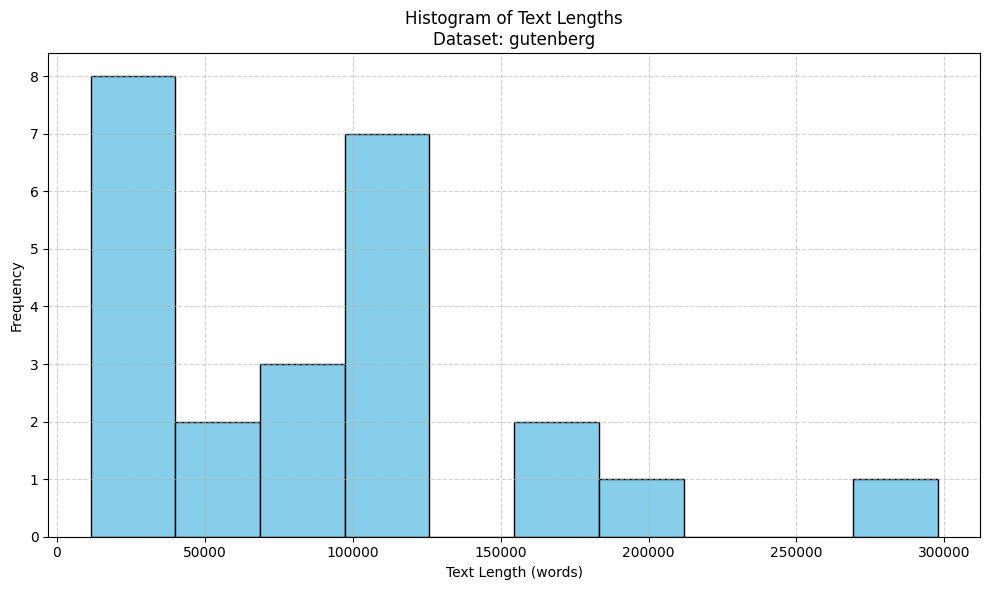

Average length (characters) per text: 87343.83


In [42]:
gutenberg.plot_text_length_histogram(
    dataset=ds_gutenberg, preprocess_fn=_split, unit="words"
)

In [43]:
print_min_len_text_sample(ds_gutenberg)

Text with minimal length 11443:
When Mr. Hiram B. Otis, the American Minister, bought Canterville Chase, every one told him he was
doing a very foolish thing, as there was no doubt at all that the place was haunted. Indeed, Lord
Canterville himself, who was a man of the most punctilious honour, had felt it his duty to mention
the f Mr. Otis when they came to discuss terms. "We have not cared to live in the place ourselves,"
said Lord Canterville, "since my grandaunt, the Dowager Duchess of Bolton, was frightened into a
fit, from which she never really recovered, by two skeleton hands being placed on her shoulders as
she was dressing for dinner, and I feel bound to tell you, Mr. Otis, that the ghost has been seen by
several living members of my family, as well as by the rector of the parish, the Rev. Augustus
Dampier, who is a Fellow of King's College, Cambridge. After the unfortunate accident to the
Duchess, none of our younger servants would stay with us, and Lady Canterville often go

In [44]:
print_max_len_text_sample(ds_gutenberg)

Text with maximal length 207731:
Call me Ishmael. Some years agonever mind how long preciselyhaving little or no money in my purse,
and nothing particular to interest me on shore, I thought I would sail about a little and see the
watery part of the world. It is a way I have of driving off the spleen and regulating the
circulation. Whenever I find myself growing grim about the mouth; whenever it is a damp, drizzly
November in my soul; whenever I find myself involuntarily pausing before coffin warehouses, and
bringing up the rear of every funeral I meet; and especially whenever my hypos get such an upper
hand of me, that it requires a strong moral principle to prevent me from deliberately stepping into
the street, and methodically knocking peoples hats offthen, I account it high time to get to sea as
soon as I can. This is my substitute for pistol and ball. With a philosophical flourish Cato throws
himself upon his sword; I quietly take to the ship. There is nothing surprising in this. I

Preprocessing example on MacBeth

In [45]:
imp_det = ImpostorDetector()
# sample_text = ds_gutenberg['pair'].iloc[0][0]
sys.path.append(os.path.abspath(".."))

with open(
    Path(os.getcwd()).resolve().parent
    / Path(CONFIG.PATH2GUTENBERG).parent
    / "Macbeth_William_Shakespeare.txt",
    "r",
) as f:
    sample_text = f.read()
print(textwrap.fill(sample_text, width=80))

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


ACT I  SCENE I. An open Place.    Thunder and Lightning. Enter three Witches.
FIRST WITCH. When shall we three meet again? In thunder, lightning, or in rain?
SECOND WITCH. When the hurlyburly’s done, When the battle’s lost and won.  THIRD
WITCH. That will be ere the set of sun.  FIRST WITCH. Where the place?  SECOND
WITCH. Upon the heath.  THIRD WITCH. There to meet with Macbeth.  FIRST WITCH. I
come, Graymalkin!  SECOND WITCH. Paddock calls.  THIRD WITCH. Anon.  ALL. Fair
is foul, and foul is fair: Hover through the fog and filthy air.   [_Exeunt._]
SCENE II. A Camp near Forres.   Alarum within. Enter King Duncan, Malcolm,
Donalbain, Lennox, with  Attendants, meeting a bleeding Captain.  DUNCAN. What
bloody man is that? He can report, As seemeth by his plight, of the revolt The
newest state.  MALCOLM. This is the sergeant Who, like a good and hardy soldier,
fought ’Gainst my captivity.—Hail, brave friend! Say to the King the knowledge
of the broil As thou didst leave it.  SOLDIER. Dou

In [46]:
normalized_text = imp_det.preprocess_text(sample_text)
print(textwrap.fill(normalized_text, width=80))

An open Place. Thunder and Lightning. Enter three Witches. When shall we three
meet again? In thunder, lightning, or in rain? When the hurlyburlys done, When
the battles lost and won. That will be ere the set of sun. Where the place? Upon
the heath. There to meet with Macbeth. I come, Graymalkin! Paddock calls. Anon.
Fair is foul, and foul is fair: Hover through the fog and filthy air. Exeunt. A
Camp near Forres. Alarum within. Enter King Duncan, Malcolm, Donalbain, Lennox,
with Attendants, meeting a bleeding Captain. What bloody man is that? He can
report, As seemeth by his plight, of the revolt The newest state. This is the
sergeant Who, like a good and hardy soldier, fought Gainst my captivity.Hail,
brave friend! Say to the King the knowledge of the broil As thou didst leave it.
Doubtful it stood; As two spent swimmers that do cling together And choke their
art. The merciless Macdonwald (Worthy to be a rebel, for to that The multiplying
villainies of nature Do swarm upon him) from t

In [47]:
gutenberg_stats = gutenberg.dataset_stats()

In [48]:
# gutenberg.plot_avg_text_length_per_author()
# gutenberg.plot_text_length_histogram(bins=50)
# gutenberg.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del gutenberg
# gc.collect()

## PAN 25

In [49]:
# pan25 = datasets.Pan25Visualization()
# pan25_stats = pan25.dataset_stats()

## Webis Koppel dataset

In [50]:
# koppel_webis = datasets.KoppelWebisVisualization()
# koppel_webis_stats = koppel_webis.dataset_stats()

In [51]:
# koppel_webis.plot_avg_text_length_per_author()
# koppel_webis.plot_text_length_histogram(bins=50)
# koppel_webis.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del koppel_webis
# gc.collect()

## Compare datasets

In [52]:
combined_stats = pd.concat(
    [
        pan20_stats,
        blog_stats,
        gutenberg_stats,
        student_essays_stats,
        # pan23_stats, koppel_webis_stats, # pan25_stats
    ],
    axis=0,
    ignore_index=True,
)  # concat rows
combined_stats.set_index("dataset", inplace=True)  # set dataset as index
save_path = Path.cwd().parent / CONFIG.SAVE_PATH / "all_data" / "statistics"
save_path.mkdir(parents=True, exist_ok=True)  # create directory if it doesn't exist
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
combined_stats.to_csv(
    save_path / f"combined_stats_{timestamp}.csv", float_format="%.2f"
)
print(f"Combined statistics saved to {save_path / f'combined_stats_{timestamp}.csv'}")

Combined statistics saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/all_data/statistics/combined_stats_20250726_235400.csv


In [53]:
display(combined_stats)

,num_pairs,num_authors,num_same_pairs,num_different_pairs,avg_text_len_chars,min_text_len_chars,max_text_len_chars,std_text_len_chars,avg_text_len_words,min_text_len_words,max_text_len_words,std_text_len_words,median_text_len_words
dataset,,,,,,,,,,,,,
pan20,66875,52741,35608,31267,21419.02,17726,296734,2682.24,3915.07,3044,55413,511.90,3889
blog,163,148,107,56,30006.51,15424,615409,36423.57,5381.42,3009,115365,6730.96,4105
gutenberg,12,7,6,6,485286.25,63938,1696684,387519.54,87339.79,11443,297704,68368.09,76660
student_essays,1284,728,642,642,3660.59,2312,9300,924.36,708.64,500,1699,182.98,655
